Predict Future Stock Prices

Objective: Predict the next day's closing price of a stock using historical stock data.
We will use features like Open, High, Low, and Volume for prediction.

In [1]:
!pip install yfinance

import yfinance as yf
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


### Import Libraries
- yfinance: Fetch historical stock data
- pandas: Handle data
- sklearn: Split data and train Linear Regression
- matplotlib: Visualize predictions


In [2]:
# Download Apple stock data from 2023-01-01 to 2025-01-01
data = yf.download("AAPL", start="2023-01-01", end="2025-01-01")
data.head()


/tmp/ipython-input-275228454.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2023-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-01-03,123.211220,128.954569,122.324594,128.343788,112117500
2023-01-04,124.482025,126.747845,123.221050,125.004147,89113600
2023-01-05,123.161949,125.871079,122.905819,125.240591,80962700
2023-01-06,127.693573,128.353614,123.033875,124.137232,87754700
2023-01-09,128.215729,131.427289,127.959598,128.530980,70790800


### Load Stock Data
- Using yfinance, we fetch historical data for Apple (AAPL)
- Data includes Open, High, Low, Close, Volume, and Adjusted Close
- .head() shows the first 5 rows


In [3]:
# Use Open, High, Low, Volume to predict Close
X = data[['Open', 'High', 'Low', 'Volume']]
y = data['Close']


### Features and Target
- Features (X): Open, High, Low, Volume
- Target (y): Close price (what we want to predict)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


### Train-Test Split
- 80% of data used to train the model
- 20% used to test predictions


In [5]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

### Model Training
Linear Regression model learns the relationship between stock features and Close price.


In [6]:
y_pred = model.predict(X_test)


### Price Prediction
The trained model predicts closing prices for the test dataset.


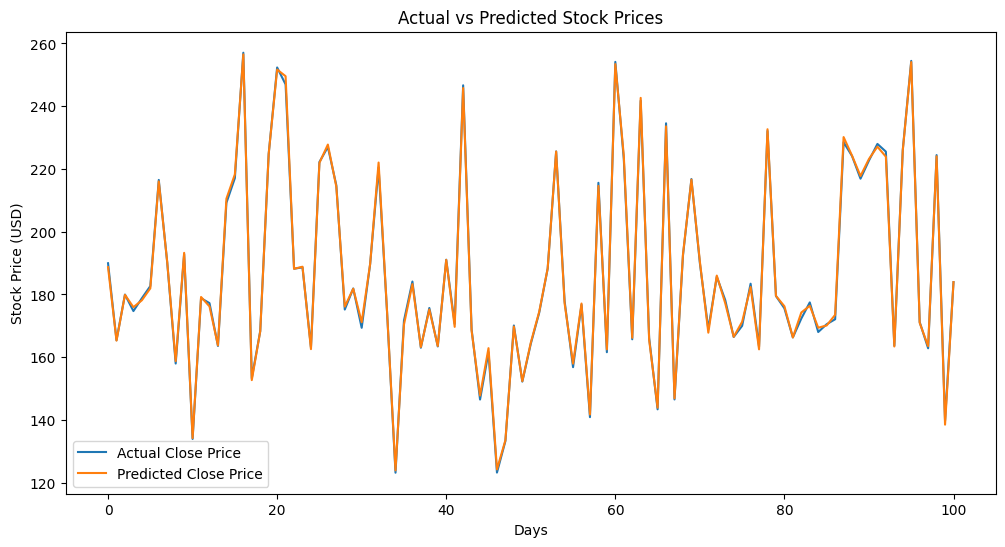

In [7]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual Close Price')
plt.plot(y_pred, label='Predicted Close Price')
plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Days")
plt.ylabel("Stock Price (USD)")
plt.legend()
plt.show()


### Visualization
- Compares actual vs predicted closing prices
- Lines close together indicate better predictions


### Conclusion
- Linear Regression can roughly predict next-day stock prices based on Open, High, Low, and Volume.
- Predictions are not perfect due to market volatility, but the model captures general trends.
- More advanced models (Random Forest, LSTM) can improve prediction accuracy.
